In [2]:
import torch
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

# 存储梯度
x = torch.arange(4.0,requires_grad=True)
x,x.grad

(tensor([0., 1., 2., 3.], requires_grad=True), None)

In [3]:
y = 2* torch.dot(x,x)
y,x

(tensor(28., grad_fn=<MulBackward0>),
 tensor([0., 1., 2., 3.], requires_grad=True))

In [4]:
# 传播函数。
# backward的返回值是此operation输入值的梯度。
y.backward()

# 2*x**2 导数 4*x
x.grad,x

(tensor([ 0.,  4.,  8., 12.]), tensor([0., 1., 2., 3.], requires_grad=True))

In [5]:
x.grad == 4*x

tensor([True, True, True, True])

In [6]:
x.grad.zero_()
y = x.sum()
y.backward()
x.grad,y

(tensor([1., 1., 1., 1.]), tensor(6., grad_fn=<SumBackward0>))

In [7]:
x.grad.zero_()
y = x*x
# y.backward(torch.ones(len(x)))
# 对一个标量求导，而不是向量
y.sum().backward()
x.grad,y.sum()

(tensor([0., 2., 4., 6.]), tensor(14., grad_fn=<SumBackward0>))

In [8]:
x.grad.zero_()
# 分离计算
y = x*x

u = y.detach()

z = u * x
z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [9]:
x.grad.zero_()
y.sum().backward()

x.grad == 2 * x

tensor([True, True, True, True])

In [10]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [11]:
a = torch.randn((1,3),requires_grad=True)
d = f(a)
d.sum().backward()
d,a

(tensor([[ 238.3295, 1250.9171,  751.6368]], grad_fn=<MulBackward0>),
 tensor([[0.2327, 1.2216, 0.7340]], requires_grad=True))

In [12]:
a.grad,a.grad == d / a,a

(tensor([[1024., 1024., 1024.]]),
 tensor([[True, True, True]]),
 tensor([[0.2327, 1.2216, 0.7340]], requires_grad=True))

In [13]:
# 将示例梯度计算简化理解
def f(x):
    return x*2
x = torch.randn(size=(),requires_grad=True)
y = f(x)
y.backward()
x,y,x.grad,y/x

(tensor(0.5684, requires_grad=True),
 tensor(1.1368, grad_fn=<MulBackward0>),
 tensor(2.),
 tensor(2., grad_fn=<DivBackward0>))

1，二阶的反向累计无向图建立在一阶之上，更为复杂

2，报错RunTimeError

3，会报错，需要先sum后backward

4，梯度简略理解为某个点导数值

5，

X点数量： 30
X点数量： 30


C:\Users\Raisei\AppData\Local\Temp/ipykernel_45032/3664809896.py:4: RuntimeWarning: divide by zero encountered in true_divide
  return x**3-1/x


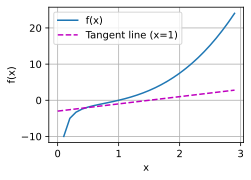

In [14]:
from plotFunction import plot

def f(x):
    return x**3-1/x

x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])



In [15]:
def f(x):
    return torch.sin(x)
    
x = torch.tensor([torch.pi/2])
# f(x)
y = f(x)
# y.backward()

X点数量： 24


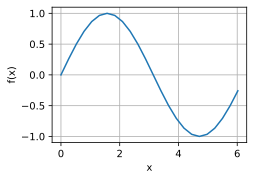

In [16]:
def f(x):
    return np.sin(x)

x = np.arange(0,2*np.pi,np.pi/12)
y = f(x)

plot(x,[f(x)],"x","f(x)")